# Springsteel.jl Tutorial

**Springsteel** is a semi-spectral grid engine for numerical modelling that combines **cubic B-splines** (radial/Cartesian), **Fourier series** (azimuthal), and **Chebyshev polynomials** (vertical) as basis functions. It provides a unified `SpringsteelGrid{G, I, J, K}` parametric type that replaces the legacy per-geometry structs while remaining fully backward-compatible.

This tutorial walks through four examples of increasing dimensionality:

1. **1D Spline** — a single radial/Cartesian dimension with cubic B-splines
2. **2D Polar (Spline × Fourier)** — cylindrical geometry with radius and azimuth
3. **3D Cylindrical (Spline × Fourier × Chebyshev)** — full 3D cylindrical with vertical Chebyshev
4. **3D Cartesian (Spline × Spline × Spline)** — three Cartesian dimensions, also demonstrating multiple variables

Each example:
- Creates a grid with `SpringsteelGridParameters` and `createGrid`
- Fills it with a Gaussian function
- Performs a **round-trip** transform: physical → spectral → physical
- Visualizes the original and reconstructed fields with **CairoMakie**

## Setup

Load Springsteel and the CairoMakie plotting backend.

In [1]:
using Springsteel
using CairoMakie

---
## Background: Basis Functions, Transforms, and Boundary Conditions

### Cubic B-Spline Basis

A domain $[x_0, x_0']$ is divided into $m$ equal cells of width $\Delta x$.  The B-spline basis function centred on node $x_n$ is a piecewise cubic of second-order continuity ($C^2$) with support on four cells:

$$\varphi_n(x) = F\!\left(\frac{x - x_n}{\Delta x}\right), \quad
F(\xi) = \begin{cases}
  \tfrac{1}{6}(1{-}|\xi|)^2[4-(2{-}3|\xi|)(1{+}3|\xi|)] & 0 \le |\xi| \le 1 \\
  \tfrac{1}{6}(2{-}|\xi|)^3 & 1 \le |\xi| \le 2 \\
  0 & |\xi| \ge 2
\end{cases}$$

A field is represented as $u(x) = \sum_{n \in M} a_n\, \varphi_n(x)$, giving $m + 3$ spectral coefficients for $m$ cells.

### Physical Sampling: The Mish

Fields are sampled at **3 Gauss–Legendre points per cell** (the "mish"), using abscissae $\pm\sqrt{3/5}$ and $0$ with weights $w = [5/18,\, 8/18,\, 5/18]$.  Total physical points: `iDim = num_cells × 3`.

### The Three-Step Transform Pipeline (Ooyama 2002, §4)

| Step | Name | Direction | Description |
|:----:|:-----|:----------|:------------|
| 1 | **SB transform** | physical → B-vector | Weighted projection onto the basis: $b_n = \sum_\text{cells} \Delta x \sum_\mu w_\mu\, \varphi_n(x_\mu)\, u(x_\mu)$ |
| 2 | **SA transform** | B-vector → spectral coefficients | Solves $a = \Gamma^T[(\Gamma(P{+}Q)\Gamma^T)^{-1}\,\Gamma\, b]$ with the boundary-condition base-folding operator $\Gamma$ |
| 3 | **SI transform** | spectral → physical | Evaluates $u(x) = \sum_n a_n\,\varphi_n(x)$ and its first and second derivatives |

`spectralTransform!(grid)` runs steps 1–2; `gridTransform!(grid)` runs step 3.

### Boundary Conditions: Rank and Type (Ooyama 2002, Eq. 3.2)

A homogeneous BC is designated **R$r$T$t$**, where the *rank* $r$ is the number of constraints (which removes $r$ border coefficients from the spectral solve), and the *type* $t$ identifies which derivative is constrained.

| Constant | Ooyama Eq. | Constraint | Physical use |
|:---------|:----------:|:-----------|:-------------|
| `CubicBSpline.R0` | 3.2a | None — free boundary | Open/interior boundaries, domain nesting |
| `CubicBSpline.R1T0` | 3.2b | $u(x_0) = 0$ | Dirichlet zero-value wall |
| `CubicBSpline.R1T1` | 3.2c | $u'(x_0) = 0$ | Neumann; symmetry / reflecting wall |
| `CubicBSpline.R1T2` | 3.2d | $u''(x_0) = 0$ | Zero curvature |
| `CubicBSpline.R2T10` | 3.2f | $u = u' = 0$ | Symmetrically reflecting boundary |
| `CubicBSpline.R2T20` | 3.2g | $u = u'' = 0$ | Antisymmetric reflection |
| `CubicBSpline.R3` | 3.2h | $u = u' = u'' = 0$ | Full constraint; precursor to R3X nesting |
| `CubicBSpline.PERIODIC` | §3e | Cyclic domain | Azimuthal / periodic domains |

The same rank/type names are used for `Chebyshev` BCs. For `Fourier`, only `PERIODIC` is valid (applied automatically).


---
## Example 1 — 1D Spline Grid

The simplest Springsteel grid uses **cubic B-splines** in a single dimension.

### Key concepts
- `SpringsteelGridParameters` configures the grid: geometry, domain bounds, boundary conditions, and variables.
- `createGrid(gp)` builds the grid and allocates physical/spectral arrays.
- `spectralTransform!(grid)` maps physical → spectral coefficients (SB + SA steps).
- `gridTransform!(grid)` maps spectral → physical including first and second derivatives (SI step).
- The physical array has shape `(iDim, n_vars, 3)` for 1D: `[f, ∂f/∂x, ∂²f/∂x²]`.

### Boundary Conditions in this example

`CubicBSpline.R0` is used at both ends — this is the **rank-0, no-constraint** condition (Ooyama 2002, Eq. 3.2a), meaning the field is unconstrained at the boundary and all border coefficients remain free. It is appropriate here because the Gaussian decays to essentially zero well before the domain edges, so no physical constraint needs to be enforced.

To enforce an actual condition at the boundary, use one of:
- `R1T0` — zero field value, $u(x_0)=0$
- `R1T1` — zero first derivative, $u'(x_0)=0$ (symmetry / Neumann)
- `R1T2` — zero second derivative, $u''(x_0)=0$

See the Background section above for the complete table.


In [2]:
# --- 1D Spline grid parameters ---
gp_1d = SpringsteelGridParameters(
    geometry  = "R",
    iMin      = -50.0,
    iMax      = 50.0,
    num_cells = 30,
    BCL       = Dict("gauss" => CubicBSpline.R0),
    BCR       = Dict("gauss" => CubicBSpline.R0),
    vars      = Dict("gauss" => 1)
)

grid_1d = createGrid(gp_1d)
println("Grid type: ", typeof(grid_1d))
println("Physical array size:  ", size(grid_1d.physical))   # (iDim, 1, 3)
println("Spectral array size:  ", size(grid_1d.spectral))   # (b_iDim, 1)

Grid type: SpringsteelGrid{CartesianGeometry, SplineBasisArray, NoBasisArray, NoBasisArray}
Physical array size:  (90, 1, 3)
Spectral array size:  (33, 1)


In [3]:
# --- Fill with a Gaussian ---
pts_1d = getGridpoints(grid_1d)   # Vector of x-coordinates
σ = 10.0                           # Gaussian width
for i in eachindex(pts_1d)
    grid_1d.physical[i, 1, 1] = exp(-(pts_1d[i] / σ)^2)
end
original_1d = copy(grid_1d.physical[:, 1, 1])

# --- Round-trip transform ---
spectralTransform!(grid_1d)
gridTransform!(grid_1d)

reconstructed_1d = grid_1d.physical[:, 1, 1]
println("Max round-trip error: ", maximum(abs.(reconstructed_1d .- original_1d)))

Max round-trip error: 0.00036055920234501215


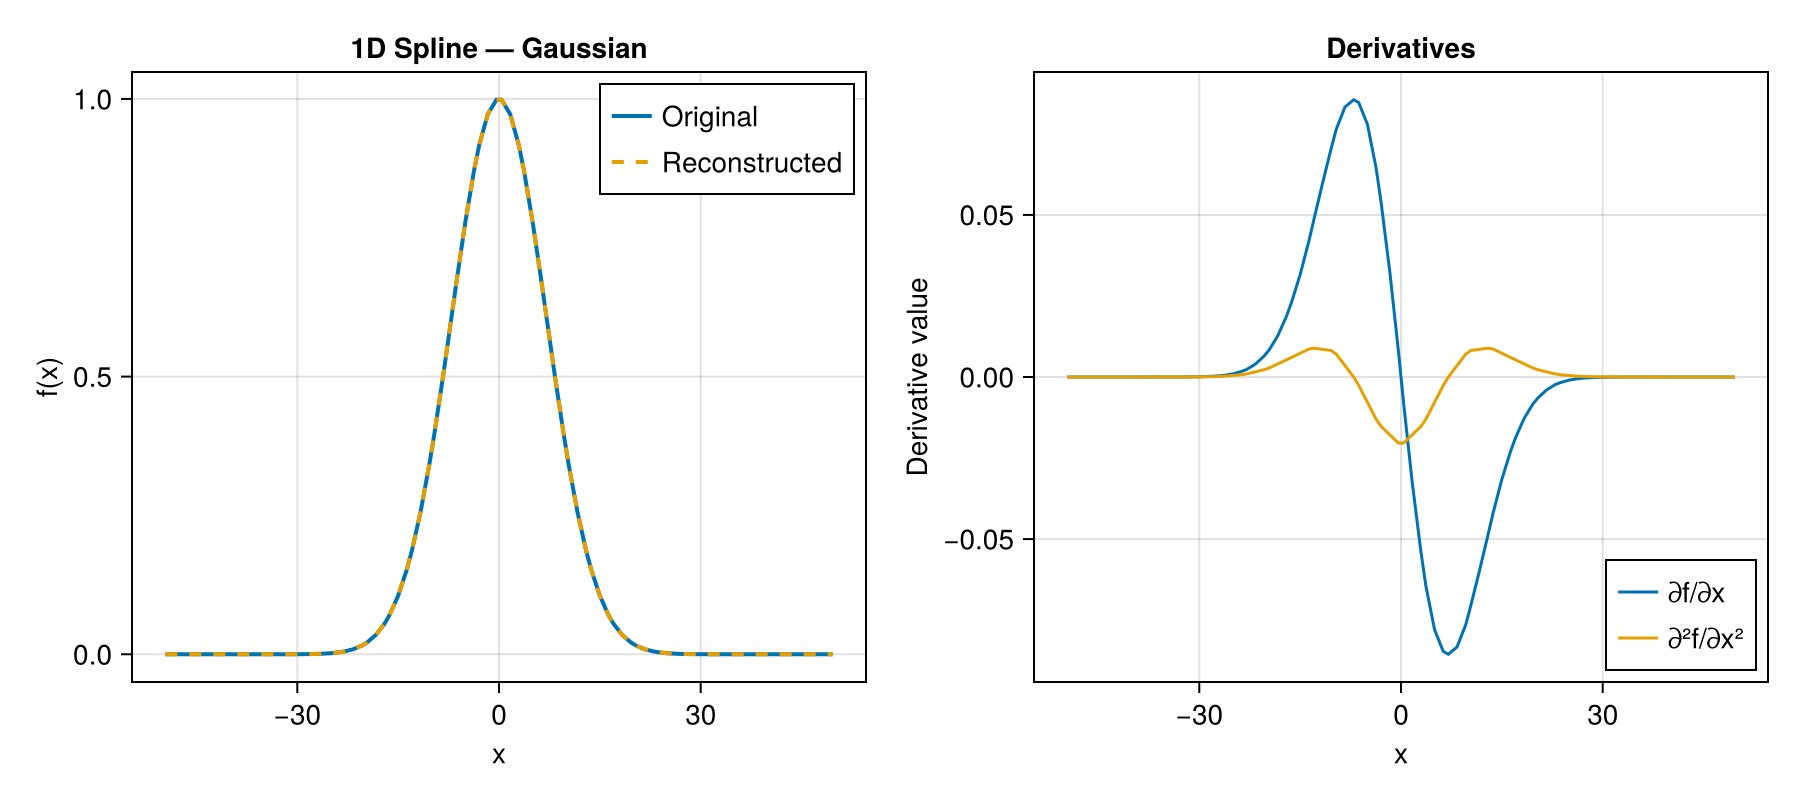

In [4]:
# --- Visualize ---
fig1 = Figure(size = (900, 400))

# Left: original vs reconstructed
ax1a = Axis(fig1[1, 1], xlabel = "x", ylabel = "f(x)",
            title = "1D Spline — Gaussian")
lines!(ax1a, pts_1d, original_1d,      label = "Original",       linewidth = 2)
lines!(ax1a, pts_1d, reconstructed_1d,  label = "Reconstructed", linewidth = 2,
       linestyle = :dash)
axislegend(ax1a, position = :rt)

# Right: derivatives computed by Springsteel
ax1b = Axis(fig1[1, 2], xlabel = "x", ylabel = "Derivative value",
            title = "Derivatives")
lines!(ax1b, pts_1d, grid_1d.physical[:, 1, 2], label = "∂f/∂x",   linewidth = 1.5)
lines!(ax1b, pts_1d, grid_1d.physical[:, 1, 3], label = "∂²f/∂x²", linewidth = 1.5)
axislegend(ax1b, position = :rb)

fig1

---
## Example 2 — 2D Polar Grid (Spline × Fourier)

A **cylindrical** (RL) grid uses B-splines in the radial direction and **Fourier series** in azimuth.

### Key concepts
- The geometry string `"RL"` selects `CylindricalGeometry` with `SplineBasisArray` (i) and `FourierBasisArray` (j).
- Each radial ring has a **different number of azimuthal gridpoints** (`lpoints = 4 + 4rᵢ`), increasing outward — this avoids over-resolving near the center.
- The physical array has 5 derivative slots for 2D: `[f, ∂f/∂r, ∂²f/∂r², ∂f/∂λ, ∂²f/∂λ²]`.
- `getGridpoints(grid)` returns an `(N, 2)` matrix with `[r, λ]` columns.

### Boundary Conditions in this example

The radial B-spline BCs use `CubicBSpline.R0` (rank-0, no constraint) at both boundaries, appropriate for a Gaussian that is negligible at the domain edges.

The azimuthal Fourier basis always uses **`PERIODIC`** (Ooyama 2002, §3e): the only valid Fourier BC, coupling the borders to simulate a cyclically continuous ring. This is set automatically by `createGrid` — no Fourier BC parameter is needed.


In [5]:
# --- 2D Polar grid ---
gp_rl = SpringsteelGridParameters(
    geometry  = "RL",
    iMin      = 0.0,
    iMax      = 100.0,
    num_cells = 10,
    vars      = Dict("gauss" => 1),
    BCL       = Dict("gauss" => CubicBSpline.R0),
    BCR       = Dict("gauss" => CubicBSpline.R0)
)

grid_rl = createGrid(gp_rl)
println("Grid type: ", typeof(grid_rl))
println("Physical array size:  ", size(grid_rl.physical))   # (jDim, 1, 5)
println("Spectral array size:  ", size(grid_rl.spectral))

Grid type: RL_Grid
Physical array size:  (1980, 1, 5)
Spectral array size:  (960, 1)


In [6]:
# --- Fill with an axisymmetric Gaussian: f(r,λ) = exp(-(r/σ)²) ---
σ_rl = 30.0
iDim_rl = grid_rl.params.iDim
g = 1
for r in 1:iDim_rl
    ri      = r + grid_rl.params.patchOffsetL
    lpoints = 4 + 4 * ri
    r_val   = grid_rl.ibasis.data[1, 1].mishPoints[r]
    val     = exp(-(r_val / σ_rl)^2)
    for l in 1:lpoints
        grid_rl.physical[g, 1, 1] = val
        g += 1
    end
end
original_rl = copy(grid_rl.physical[:, 1, 1])

# --- Round-trip ---
spectralTransform!(grid_rl)
gridTransform!(grid_rl)

reconstructed_rl = grid_rl.physical[:, 1, 1]
println("Max round-trip error: ", maximum(abs.(reconstructed_rl .- original_rl)))

Max round-trip error: 0.0015929026438026295


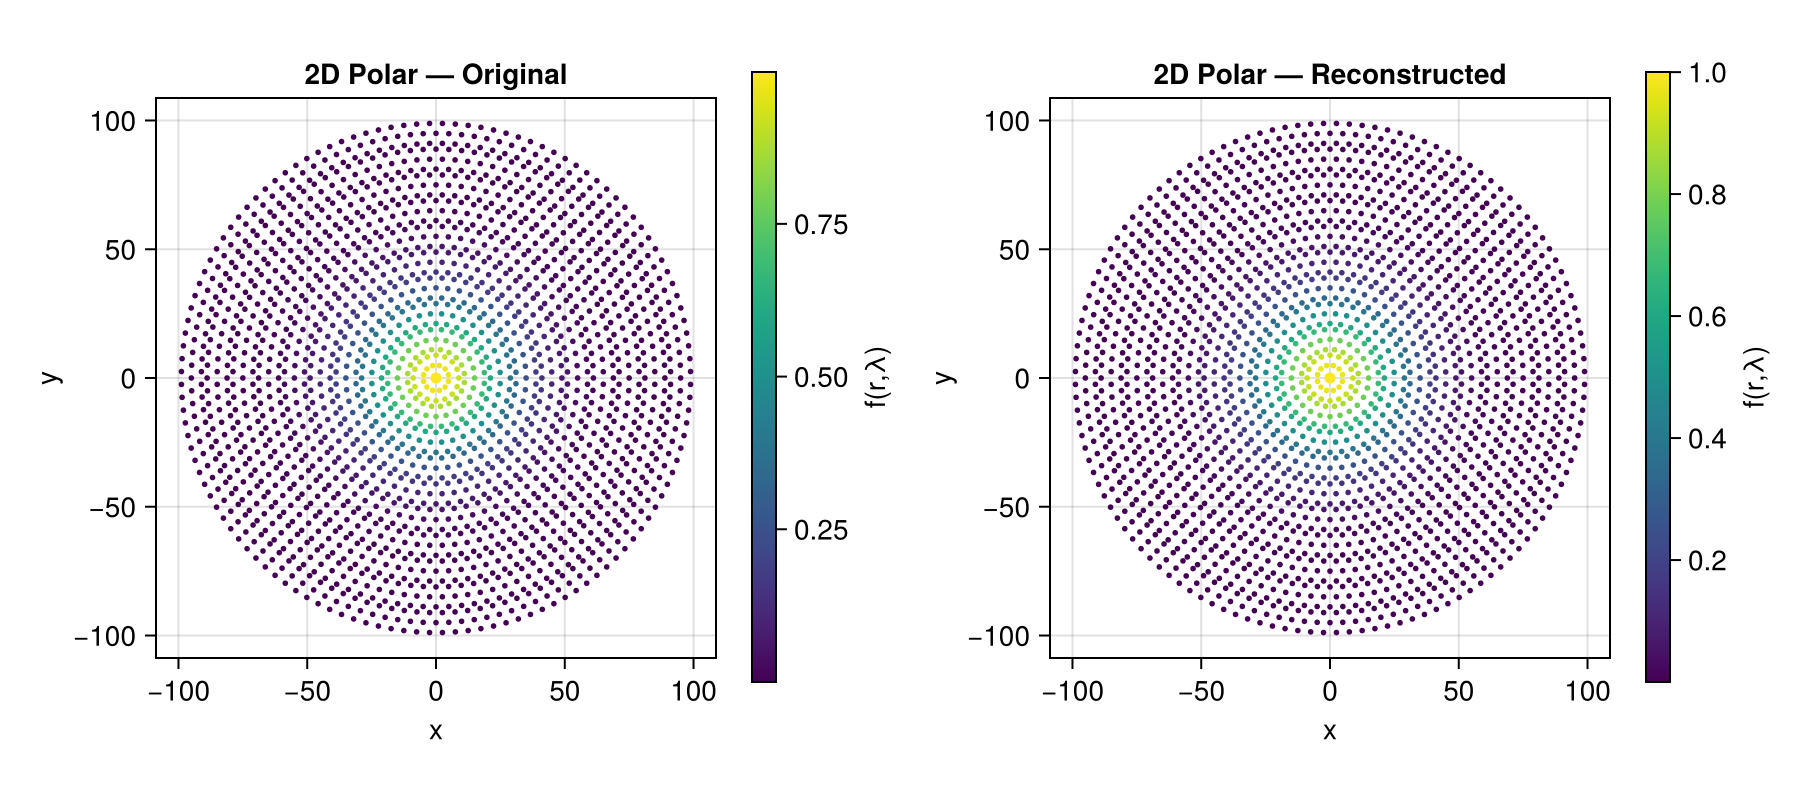

In [7]:
# --- Visualize as polar scatter ---
pts_rl = getGridpoints(grid_rl)   # (N, 2) matrix: [r, λ]
r_vals = pts_rl[:, 1]
λ_vals = pts_rl[:, 2]

# Convert polar → Cartesian for plotting
x_rl = r_vals .* cos.(λ_vals)
y_rl = r_vals .* sin.(λ_vals)

fig2 = Figure(size = (900, 400))

ax2a = Axis(fig2[1, 1], xlabel = "x", ylabel = "y",
            title = "2D Polar — Original", aspect = DataAspect())
sc2a = scatter!(ax2a, x_rl, y_rl, color = original_rl,
                colormap = :viridis, markersize = 4)
Colorbar(fig2[1, 2], sc2a, label = "f(r,λ)")

ax2b = Axis(fig2[1, 3], xlabel = "x", ylabel = "y",
            title = "2D Polar — Reconstructed", aspect = DataAspect())
sc2b = scatter!(ax2b, x_rl, y_rl, color = reconstructed_rl,
                colormap = :viridis, markersize = 4)
Colorbar(fig2[1, 4], sc2b, label = "f(r,λ)")

fig2

---
## Example 3 — 3D Cylindrical Grid (Spline × Fourier × Chebyshev)

The **RLZ** grid combines all three basis types: B-splines in radius, Fourier in azimuth, and **Chebyshev polynomials** in the vertical.

### Key concepts
- Chebyshev parameters: `kMin`, `kMax` set vertical bounds; `kDim` sets the number of Chebyshev–Gauss–Lobatto gridpoints (clustered near both ends).
- The physical array has 7 derivative slots for 3D: `[f, ∂f/∂r, ∂²f/∂r², ∂f/∂λ, ∂²f/∂λ², ∂f/∂z, ∂²f/∂z²]`.
- Physical indexing: for each radius `r`, `lpoints` azimuthal points each with `kDim` vertical points, packed sequentially.

### Boundary Conditions in this example

- **Radial** `CubicBSpline.R0` — rank-0, no constraint (free boundary). Appropriate here because the Gaussian is negligible at r = 80.
- **Azimuthal** `PERIODIC` — set automatically by `createGrid` (the only valid Fourier BC).
- **Vertical** `Chebyshev.R0` at top and bottom — again rank-0, no constraint. This choice is appropriate for a Gaussian centred midway in z that decays to zero at both ends. To enforce a zero-value condition at the vertical boundary, use `Chebyshev.R1T0` instead ($u(z_0)=0$, Ooyama 2002 Eq. 3.2b).


In [8]:
# --- 3D Cylindrical grid ---
gp_rlz = SpringsteelGridParameters(
    geometry  = "RLZ",
    iMin      = 0.0,
    iMax      = 80.0,
    num_cells = 6,
    kMin      = 0.0,
    kMax      = 20.0,
    kDim      = 10,
    vars      = Dict("gauss" => 1),
    BCL       = Dict("gauss" => CubicBSpline.R0),
    BCR       = Dict("gauss" => CubicBSpline.R0),
    BCB       = Dict("gauss" => Chebyshev.R0),
    BCT       = Dict("gauss" => Chebyshev.R0)
)

grid_rlz = createGrid(gp_rlz)
println("Grid type: ", typeof(grid_rlz))
println("Physical array size:  ", size(grid_rlz.physical))   # (total_pts, 1, 7)
println("Spectral array size:  ", size(grid_rlz.spectral))

Grid type: RLZ_Grid
Physical array size:  (7560, 1, 7)
Spectral array size:  (2331, 1)


In [9]:
# --- Fill with a 3D Gaussian: f(r,λ,z) = exp(-(r/σ_r)² - ((z-z₀)/σ_z)²) ---
σ_r  = 25.0
σ_z  = 5.0
z₀   = (gp_rlz.kMin + gp_rlz.kMax) / 2   # centered vertically

iDim_rlz = grid_rlz.params.iDim
kDim_rlz = grid_rlz.params.kDim
idx = 1
for r in 1:iDim_rlz
    ri      = r + grid_rlz.params.patchOffsetL
    lpoints = 4 + 4 * ri
    r_val   = grid_rlz.ibasis.data[1, 1].mishPoints[r]
    for l in 1:lpoints
        for z in 1:kDim_rlz
            z_val = grid_rlz.kbasis.data[1].mishPoints[z]
            grid_rlz.physical[idx, 1, 1] = exp(-(r_val/σ_r)^2 - ((z_val - z₀)/σ_z)^2)
            idx += 1
        end
    end
end
original_rlz = copy(grid_rlz.physical[:, 1, 1])

# --- Round-trip ---
spectralTransform!(grid_rlz)
gridTransform!(grid_rlz)

reconstructed_rlz = grid_rlz.physical[:, 1, 1]
println("Max round-trip error: ", maximum(abs.(reconstructed_rlz .- original_rlz)))

Max round-trip error: 0.010963166199710397


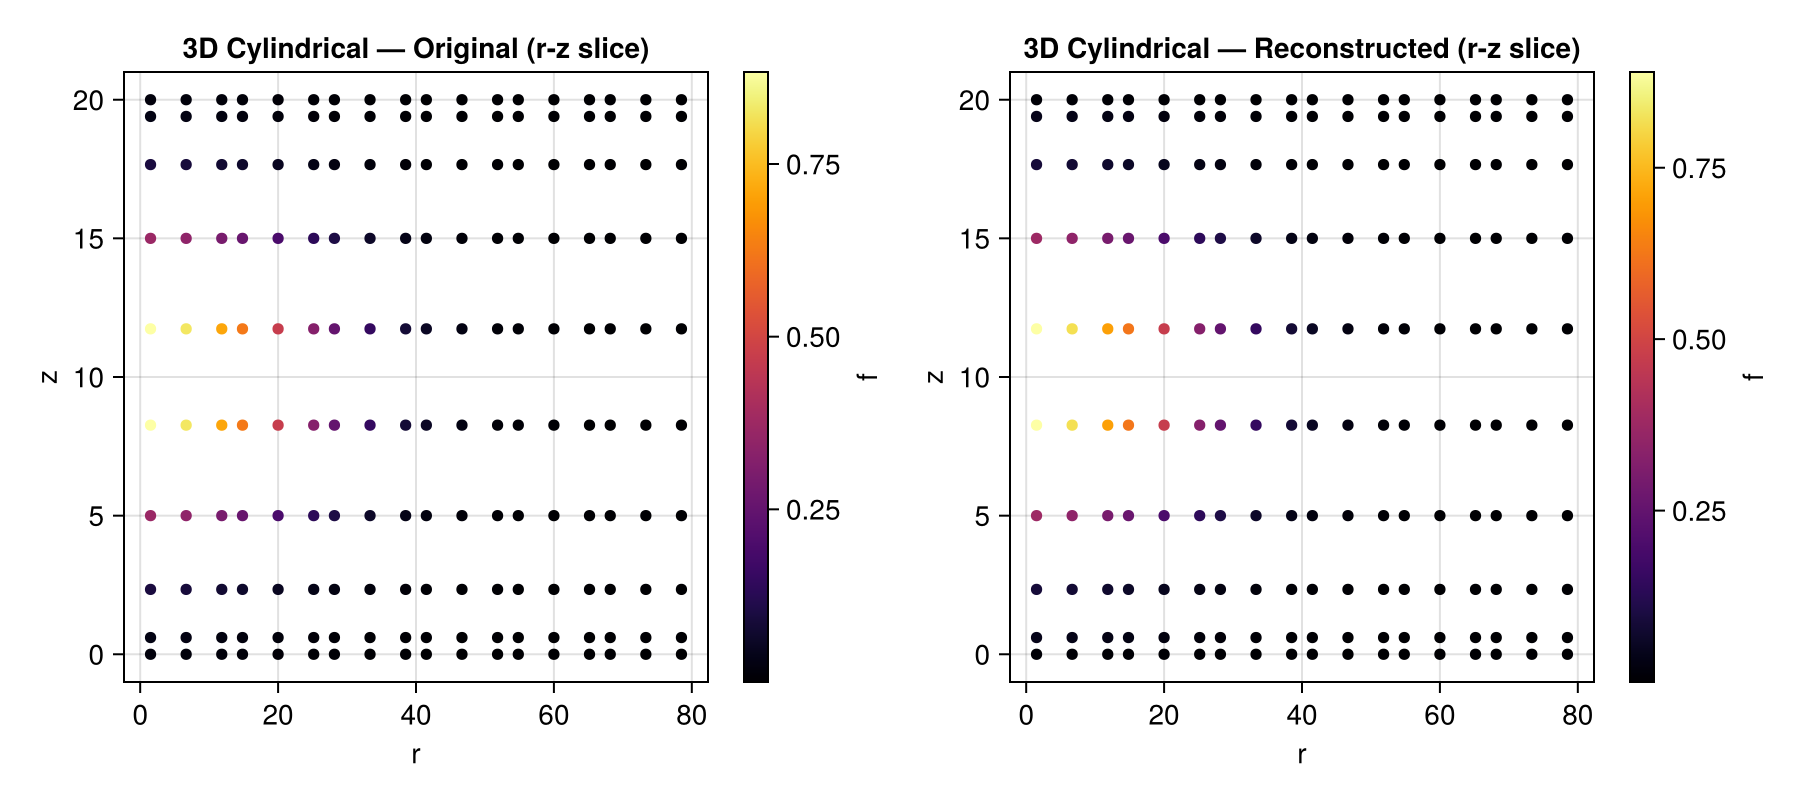

In [10]:
# --- Visualize a radial-vertical cross-section at λ = 0 (first azimuthal point per ring) ---
r_cross = Float64[]
z_cross = Float64[]
f_orig  = Float64[]
f_recon = Float64[]

idx = 1
for r in 1:iDim_rlz
    ri      = r + grid_rlz.params.patchOffsetL
    lpoints = 4 + 4 * ri
    r_val   = grid_rlz.ibasis.data[1, 1].mishPoints[r]
    for l in 1:lpoints
        for z in 1:kDim_rlz
            if l == 1   # first azimuthal point
                z_val = grid_rlz.kbasis.data[1].mishPoints[z]
                push!(r_cross, r_val)
                push!(z_cross, z_val)
                push!(f_orig,  original_rlz[idx])
                push!(f_recon, reconstructed_rlz[idx])
            end
            idx += 1
        end
    end
end

fig3 = Figure(size = (900, 400))

ax3a = Axis(fig3[1, 1], xlabel = "r", ylabel = "z",
            title = "3D Cylindrical — Original (r-z slice)")
sc3a = scatter!(ax3a, r_cross, z_cross, color = f_orig,
                colormap = :inferno, markersize = 8)
Colorbar(fig3[1, 2], sc3a, label = "f")

ax3b = Axis(fig3[1, 3], xlabel = "r", ylabel = "z",
            title = "3D Cylindrical — Reconstructed (r-z slice)")
sc3b = scatter!(ax3b, r_cross, z_cross, color = f_recon,
                colormap = :inferno, markersize = 8)
Colorbar(fig3[1, 4], sc3b, label = "f")

fig3

---
## Example 4 — 3D Cartesian Grid (Spline × Spline × Spline) with Two Variables

The **RRR** grid uses cubic B-splines in all three dimensions — a pure tensor-product grid.

### Key concepts
- All three dimensions require B-spline BCs: `BCL`/`BCR` (i-direction), `BCU`/`BCD` (j-direction), `BCB`/`BCT` (k-direction).
- Physical indexing: `flat = (i-1)*jDim*kDim + (j-1)*kDim + k` — k varies fastest.
- Multiple variables: `vars = Dict("u" => 1, "v" => 2)` assigns each variable an integer index.
- BCs are specified **per variable** in the Dict; each variable can have independent BCs.
- `getGridpoints(grid)` returns an `(N, 3)` matrix with `[x, y, z]` columns.

### Boundary Conditions in this example

All six faces use `CubicBSpline.R0` (rank-0, no constraint) for both variables. The Gaussians used in this example are negligible at all six domain faces (the domain is $[-30,30]^3$ and $\sigma \le 20$), so no physical constraint needs to be enforced.

For a model with a true physical wall (e.g. a no-slip surface at $z = -30$), you would use `BCB = Dict("u" => CubicBSpline.R1T0, ...)` to impose $u=0$ (Dirichlet), or `BCB = Dict("u" => CubicBSpline.R1T1, ...)` for zero normal derivative (Neumann).


In [11]:
# --- 3D Cartesian grid with two variables ---
gp_rrr = SpringsteelGridParameters(
    geometry  = "RRR",
    iMin      = -30.0,
    iMax      = 30.0,
    num_cells = 6,
    jMin      = -30.0,
    jMax      = 30.0,
    kMin      = -30.0,
    kMax      = 30.0,
    vars      = Dict("u" => 1, "v" => 2),
    BCL       = Dict("u" => CubicBSpline.R0, "v" => CubicBSpline.R0),
    BCR       = Dict("u" => CubicBSpline.R0, "v" => CubicBSpline.R0),
    BCU       = Dict("u" => CubicBSpline.R0, "v" => CubicBSpline.R0),
    BCD       = Dict("u" => CubicBSpline.R0, "v" => CubicBSpline.R0),
    BCB       = Dict("u" => CubicBSpline.R0, "v" => CubicBSpline.R0),
    BCT       = Dict("u" => CubicBSpline.R0, "v" => CubicBSpline.R0)
)

grid_rrr = createGrid(gp_rrr)
println("Grid type: ", typeof(grid_rrr))
println("Physical array size:  ", size(grid_rrr.physical))   # (iDim*jDim*kDim, 2, 7)
println("Spectral array size:  ", size(grid_rrr.spectral))
println("Number of variables:  ", size(grid_rrr.physical, 2))
println("Derivative slots:     ", size(grid_rrr.physical, 3), " [f, ∂f/∂x, ∂²f/∂x², ∂f/∂y, ∂²f/∂y², ∂f/∂z, ∂²f/∂z²]")

Grid type: RRR_Grid
Physical array size:  (5832, 2, 7)
Spectral array size:  (729, 2)
Number of variables:  2
Derivative slots:     7 [f, ∂f/∂x, ∂²f/∂x², ∂f/∂y, ∂²f/∂y², ∂f/∂z, ∂²f/∂z²]


In [12]:
# --- Fill with Gaussians ---
# u: isotropic 3D Gaussian   f(x,y,z) = exp(-(x²+y²+z²)/σ²)
# v: anisotropic Gaussian    g(x,y,z) = exp(-x²/σ_x² - y²/σ_y²) * z/zmax
pts_rrr = getGridpoints(grid_rrr)   # (N, 3)

σ_iso = 15.0
σ_x   = 20.0
σ_y   = 10.0

for i in 1:size(pts_rrr, 1)
    x, y, z = pts_rrr[i, 1], pts_rrr[i, 2], pts_rrr[i, 3]
    grid_rrr.physical[i, 1, 1] = exp(-(x^2 + y^2 + z^2) / σ_iso^2)
    grid_rrr.physical[i, 2, 1] = exp(-x^2/σ_x^2 - y^2/σ_y^2) * (z / gp_rrr.kMax)
end

orig_u = copy(grid_rrr.physical[:, 1, 1])
orig_v = copy(grid_rrr.physical[:, 2, 1])

# --- Round-trip ---
spectralTransform!(grid_rrr)
gridTransform!(grid_rrr)

err_u = maximum(abs.(grid_rrr.physical[:, 1, 1] .- orig_u))
err_v = maximum(abs.(grid_rrr.physical[:, 2, 1] .- orig_v))
println("Max round-trip error (u): ", err_u)
println("Max round-trip error (v): ", err_v)

Max round-trip error (u): 0.02039035469649253
Max round-trip error (v): 0.04487493015010624


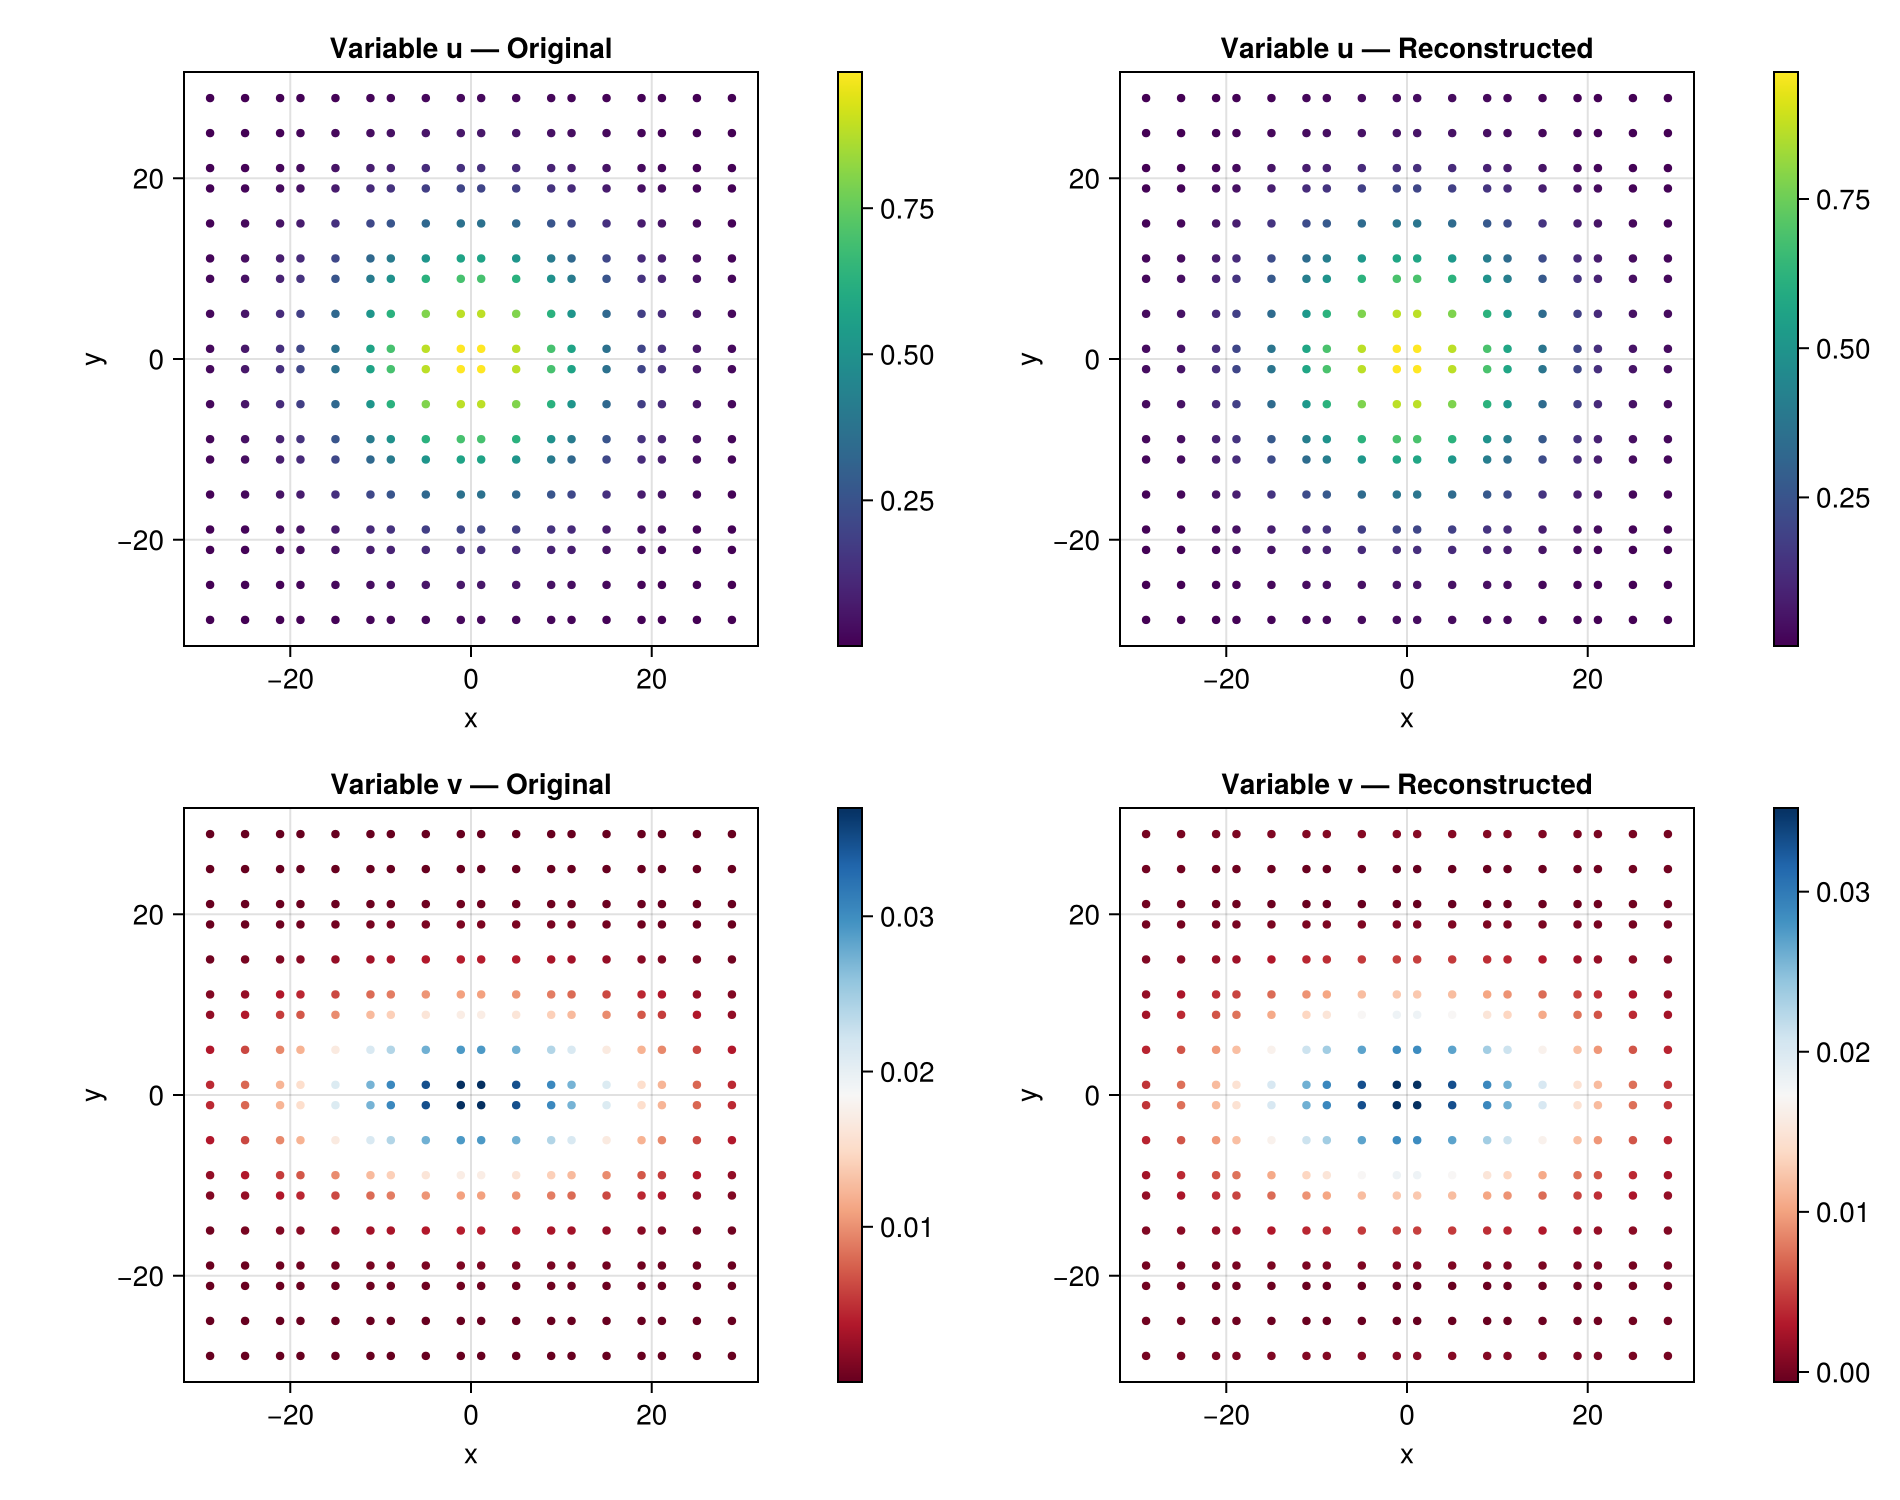

In [13]:
# --- Visualize an x-y slice at the middle k-index ---
iDim_r = grid_rrr.params.iDim
jDim_r = grid_rrr.params.jDim
kDim_r = grid_rrr.params.kDim
k_mid  = div(kDim_r, 2) + 1   # middle z-index

# Extract x-y coordinates and field values at z = z_mid
n_xy = iDim_r * jDim_r
x_slice = zeros(n_xy)
y_slice = zeros(n_xy)
u_orig_slice  = zeros(n_xy)
u_recon_slice = zeros(n_xy)
v_orig_slice  = zeros(n_xy)
v_recon_slice = zeros(n_xy)

idx = 1
for i in 1:iDim_r, j in 1:jDim_r
    flat = (i-1)*jDim_r*kDim_r + (j-1)*kDim_r + k_mid
    x_slice[idx] = pts_rrr[flat, 1]
    y_slice[idx] = pts_rrr[flat, 2]
    u_orig_slice[idx]  = orig_u[flat]
    u_recon_slice[idx] = grid_rrr.physical[flat, 1, 1]
    v_orig_slice[idx]  = orig_v[flat]
    v_recon_slice[idx] = grid_rrr.physical[flat, 2, 1]
    idx += 1
end

fig4 = Figure(size = (950, 750))

ax4a = Axis(fig4[1, 1], xlabel = "x", ylabel = "y",
            title = "Variable u — Original", aspect = DataAspect())
sc4a = scatter!(ax4a, x_slice, y_slice, color = u_orig_slice,
                colormap = :viridis, markersize = 6)
Colorbar(fig4[1, 2], sc4a)

ax4b = Axis(fig4[1, 3], xlabel = "x", ylabel = "y",
            title = "Variable u — Reconstructed", aspect = DataAspect())
sc4b = scatter!(ax4b, x_slice, y_slice, color = u_recon_slice,
                colormap = :viridis, markersize = 6)
Colorbar(fig4[1, 4], sc4b)

ax4c = Axis(fig4[2, 1], xlabel = "x", ylabel = "y",
            title = "Variable v — Original", aspect = DataAspect())
sc4c = scatter!(ax4c, x_slice, y_slice, color = v_orig_slice,
                colormap = :RdBu, markersize = 6)
Colorbar(fig4[2, 2], sc4c)

ax4d = Axis(fig4[2, 3], xlabel = "x", ylabel = "y",
            title = "Variable v — Reconstructed", aspect = DataAspect())
sc4d = scatter!(ax4d, x_slice, y_slice, color = v_recon_slice,
                colormap = :RdBu, markersize = 6)
Colorbar(fig4[2, 4], sc4d)

fig4

---
## Summary

| Grid | Geometry String | Basis Functions | Type Alias |
|------|----------------|-----------------|------------|
| 1D Radial | `"R"` or `"Spline1D"` | Spline | `R_Grid` / `Spline1D_Grid` |
| 2D Polar | `"RL"` | Spline × Fourier | `RL_Grid` |
| 2D Axisymmetric | `"RZ"` | Spline × Chebyshev | `RZ_Grid` |
| 2D Cartesian | `"RR"` or `"Spline2D"` | Spline × Spline | `RR_Grid` / `Spline2D_Grid` |
| 3D Cylindrical | `"RLZ"` | Spline × Fourier × Chebyshev | `RLZ_Grid` |
| 3D Cartesian | `"RRR"` | Spline × Spline × Spline | `RRR_Grid` |

### Core workflow
```julia
gp   = SpringsteelGridParameters(geometry = "...", ...)  # configure
grid = createGrid(gp)                                     # build
grid.physical[:, var, 1] .= your_data                     # fill
spectralTransform!(grid)                                   # physical → spectral
gridTransform!(grid)                                       # spectral → physical + derivatives
```

### Derivative slot layout
| Dim | Slots | Contents |
|-----|-------|----------|
| 1D  | 3     | `[f, ∂f/∂i, ∂²f/∂i²]` |
| 2D  | 5     | `[f, ∂f/∂i, ∂²f/∂i², ∂f/∂j, ∂²f/∂j²]` |
| 3D  | 7     | `[f, ∂f/∂i, ∂²f/∂i², ∂f/∂j, ∂²f/∂j², ∂f/∂k, ∂²f/∂k²]` |

All legacy type names (`R_Grid`, `RL_Grid`, etc.) remain available as type aliases for backward compatibility.